In [29]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [30]:
class KozaiSystem:
    """
    Stores physical parameters of a hierarchical triple system
    in the test-particle, quadrupole approximation.
    """

    def __init__(self, A=1.0):
        """
        Parameters
        ----------
        A : float
            Dimensionless Kozai coupling constant
            (sets the secular timescale).
        """
        self.A = A


class KozaiIntegrator:
    """
    Integrates quadrupole-level Kozai–Lidov equations.
    """

    def __init__(self, system: KozaiSystem):
        self.system = system

    def equations(self, t, y):
        """
        Quadrupole Kozai–Lidov equations.

        Variables
        ---------
        y[0] = e      (eccentricity)
        y[1] = i      (inclination, radians)
        y[2] = omega  (argument of periapsis, radians)
        """
        e, inc, omega = y
        A = self.system.A

        # Avoid singularities
        if e >= 1.0:
            e = 0.999999

        de_dt = A * e * np.sin(inc)**2 * np.sin(2 * omega)

        di_dt = (
            -A * (e**2 / np.sqrt(1 - e**2))
            * np.sin(inc) * np.sin(2 * omega)
        )

        domega_dt = A * (
            2 + 3 * e**2 - 5 * np.sin(inc)**2 * np.sin(omega)**2
        )

        return [de_dt, di_dt, domega_dt]

    def integrate(self, y0, t_span, n_steps=5000):
        """
        Integrate the secular equations.

        Parameters
        ----------
        y0 : list
            Initial conditions [e0, i0, omega0]
        t_span : tuple
            (t_start, t_end)
        n_steps : int
            Number of time samples
        """
        t_eval = np.linspace(t_span[0], t_span[1], n_steps)

        sol = solve_ivp(
            self.equations,
            t_span,
            y0,
            t_eval=t_eval,
            method="RK45",
            rtol=1e-9,
            atol=1e-9
        )

        return sol
    
def kozai_constant(e, inc):
        """Kozai integral: should be conserved."""
        return np.sqrt(1 - e**2) * np.cos(inc)


def critical_inclination():
        """Critical Kozai angle in radians."""
        return np.arccos(np.sqrt(3 / 5))


In [31]:
# System and integrator
system = KozaiSystem(A=1.0)
integrator = KozaiIntegrator(system)

# Initial conditions
e0 = 0.1
i0 = np.radians(60)     # above critical angle
omega0 = np.pi / 4

# Semi-major axis (constant at quadrupole order)
a0 = 1.0

sol = integrator.integrate(
    y0=[e0, i0, omega0],
    t_span=(0, 80),
    n_steps=6000
)

t = sol.t
e, inc, omega = sol.y
a = np.full_like(t, a0)


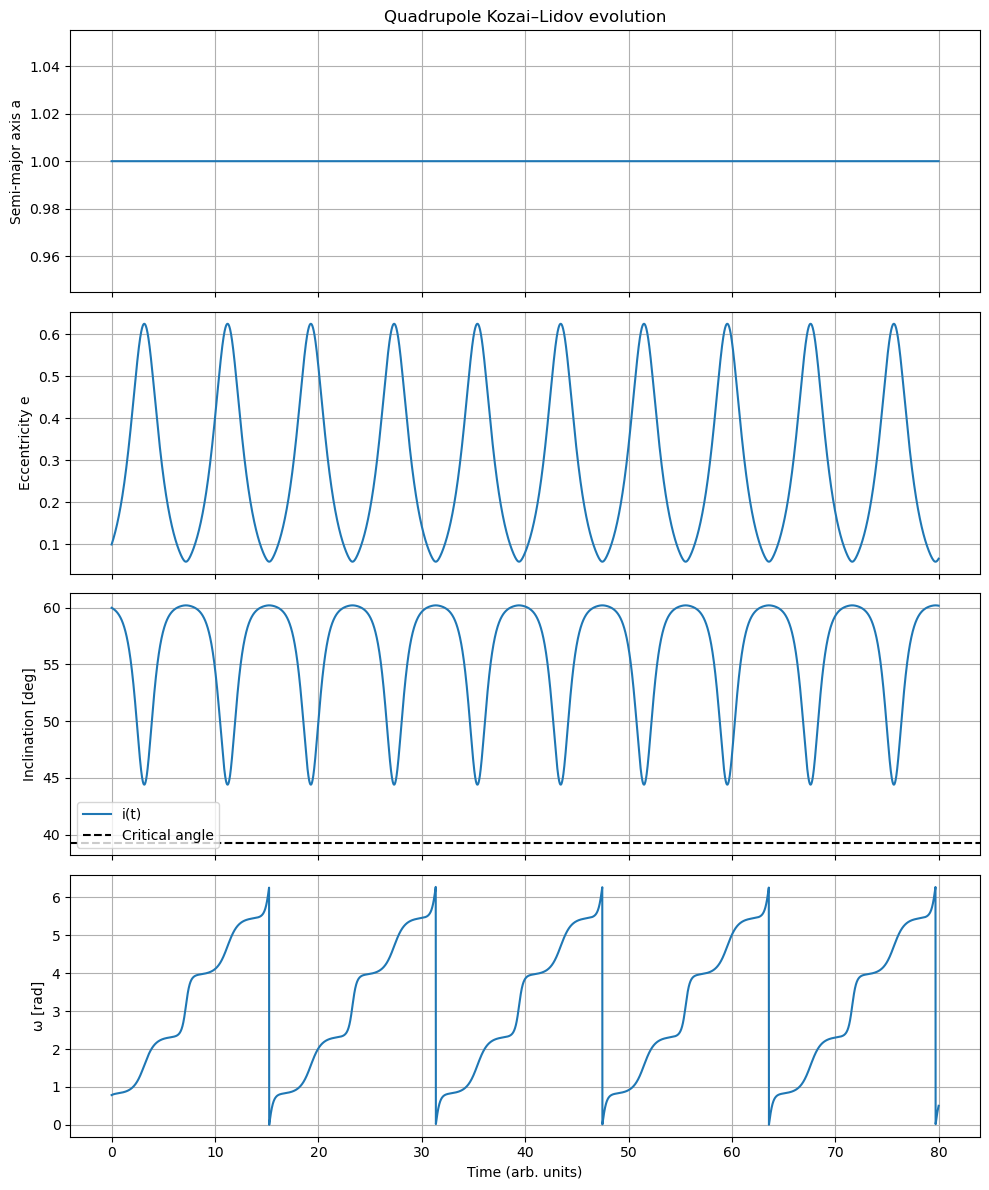

In [32]:
i_crit = critical_inclination()

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Semi-major axis
axes[0].plot(t, a)
axes[0].set_ylabel("Semi-major axis a")
axes[0].set_title("Quadrupole Kozai–Lidov evolution")
axes[0].grid()

# Eccentricity
axes[1].plot(t, e)
axes[1].set_ylabel("Eccentricity e")
axes[1].grid()

# Inclination
axes[2].plot(t, np.degrees(inc), label="i(t)")
axes[2].axhline(np.degrees(i_crit), color="k", linestyle="--",
                label="Critical angle")
axes[2].set_ylabel("Inclination [deg]")
axes[2].legend()
axes[2].grid()

# Argument of pericenter
axes[3].plot(t, np.mod(omega, 2*np.pi))
axes[3].set_ylabel("ω [rad]")
axes[3].set_xlabel("Time (arb. units)")
axes[3].grid()

plt.tight_layout()
plt.show()


In [33]:
omega_grid = np.linspace(0, 2*np.pi, 100)
inc_grid = np.linspace(
    np.radians(10),
    np.radians(80),
    80
)

e0 = 0.1


In [34]:
from tqdm import tqdm

e_max_map = np.zeros((len(inc_grid), len(omega_grid)))

for i, inc0 in enumerate(tqdm(inc_grid, desc="Inclination grid")):
    for j, omega0 in enumerate(omega_grid):

        sol = integrator.integrate(
            y0=[e0, inc0, omega0],
            t_span=(0, 20),
            n_steps=800
        )

        e_max_map[i, j] = sol.y[0].max()


Inclination grid: 100%|████████████████████████████████████████████████████████████████| 80/80 [24:14<00:00, 18.18s/it]


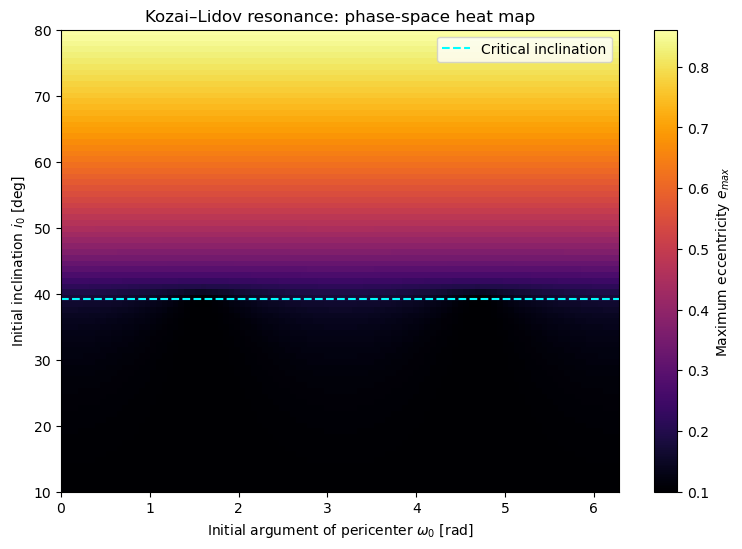

In [35]:
plt.figure(figsize=(9, 6))

extent = [
    0, 2*np.pi,
    np.degrees(inc_grid[0]),
    np.degrees(inc_grid[-1])
]

plt.imshow(
    e_max_map,
    extent=extent,
    origin="lower",
    aspect="auto",
    cmap="inferno"
)

plt.colorbar(label="Maximum eccentricity $e_{max}$")

plt.xlabel("Initial argument of pericenter $\\omega_0$ [rad]")
plt.ylabel("Initial inclination $i_0$ [deg]")
plt.title("Kozai–Lidov resonance: phase-space heat map")

# Critical angle
plt.axhline(
    np.degrees(critical_inclination()),
    color="cyan",
    linestyle="--",
    label="Critical inclination"
)

plt.legend()
plt.show()


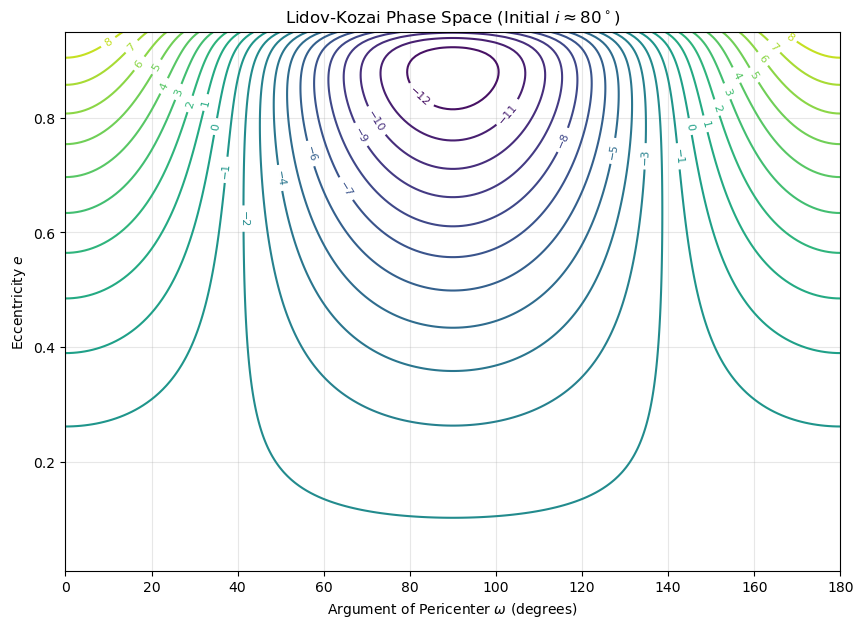

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the Grid
# omega (argument of pericenter) from 0 to 180 degrees
# e (eccentricity) from 0 to 1 (avoiding exactly 1 for stability)
omega = np.linspace(0, np.pi, 200)
ecc = np.linspace(0.01, 0.95, 200)
W, E = np.meshgrid(omega, ecc)

# 2. Define the Conservation Constant
# We choose an initial inclination that triggers resonance (i > 39.2 degrees)
i_initial = np.radians(80)
Lz = np.sqrt(1 - 0.1**2) * np.cos(i_initial)

def calculate_hamiltonian(W, E, Lz):
    # Calculate inclination from conserved Lz: cos(i) = Lz / sqrt(1 - e^2)
    # We must mask values where Lz / sqrt(1 - e^2) > 1 (physically impossible)
    cos_i_sq = Lz**2 / (1 - E**2)
    sin_i_sq = 1 - cos_i_sq
    
    # Mask unphysical regions (where inclination wouldn't exist for that e and Lz)
    sin_i_sq[sin_i_sq < 0] = np.nan
    
    # Lidov-Kozai Hamiltonian (Quadrupole)
    term1 = (2 + 3*E**2) * (3*cos_i_sq - 1)
    term2 = 15 * E**2 * sin_i_sq * np.cos(2*W)
    return term1 + term2

# 3. Compute Energy Map
Z = calculate_hamiltonian(W, E, Lz)

# 4. Visualization
plt.figure(figsize=(10, 7))
cp = plt.contour(np.degrees(W), E, Z, levels=25, cmap='viridis')
plt.clabel(cp, inline=True, fontsize=8)

plt.title(f'Lidov-Kozai Phase Space (Initial $i \\approx {int(np.degrees(i_initial))}^\circ$)')
plt.xlabel('Argument of Pericenter $\omega$ (degrees)')
plt.ylabel('Eccentricity $e$')
plt.grid(alpha=0.3)
plt.show()

C:\Users\ylana\AppData\Local\Temp\ipykernel_24312\1206084757.py:91: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(kozai_lidov_octupole, y0, t, args=(eps_oct,))


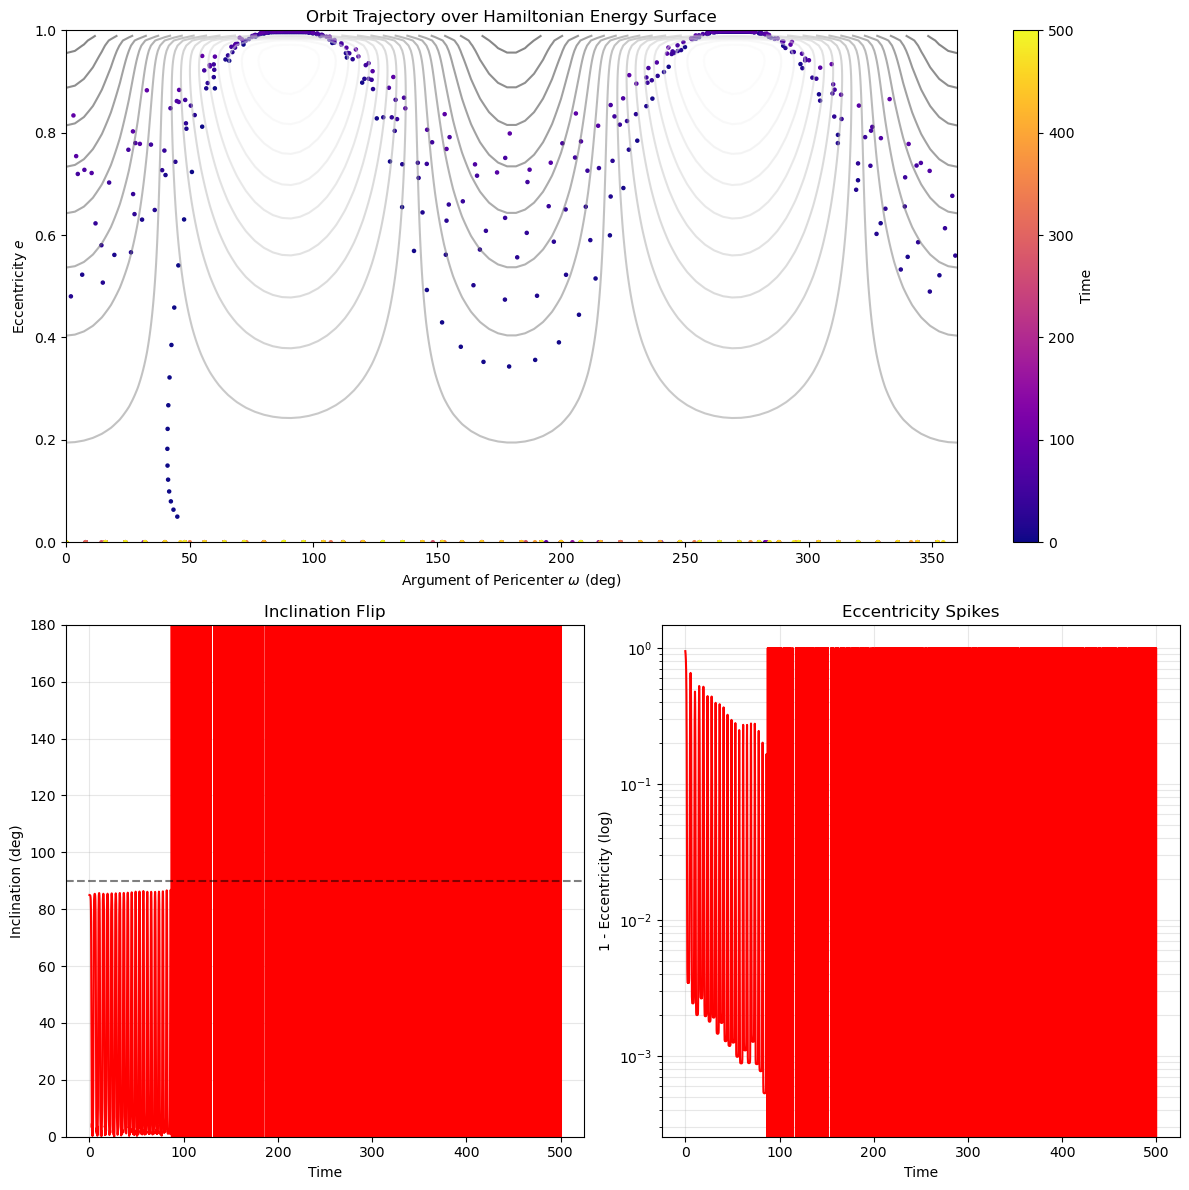

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

import numpy as np

def kozai_lidov_octupole(y, t, eps_oct):
    """
    Test-particle Kozai–Lidov equations
    Quadrupole + Octupole (dimensionless units)

    Based on:
    Lithwick & Naoz 2011
    Naoz 2016 review (Eqs 24–27, test-particle limit)
    """

    e, i, w, O = y

    # Trig shortcuts
    si, ci = np.sin(i), np.cos(i)
    sw, cw = np.sin(w), np.cos(w)

    e2 = e*e
    oms2 = 1 - e2
    oms = np.sqrt(oms2)

    # Avoid singularities
    if oms < 1e-6:
        oms = 1e-6
    if si < 1e-6:
        si = 1e-6

    # =========================
    # QUADRUPOLE TERMS
    # =========================

    de_Q = (15/8) * e * oms * si**2 * np.sin(2*w)

    di_Q = -(15/8) * e2 / oms * np.sin(2*i) * np.sin(2*w) / 2

    dw_Q = (3/(4*oms)) * (
        2*(1 - e2) + 5*si**2*(e2 - sw**2)
    )

    dO_Q = -(3/(4*oms)) * ci * (
        2 + 3*e2 - 5*e2*np.cos(2*w)
    )

    # =========================
    # OCTUPOLE TERMS
    # =========================
    # Critical angle
    phi = w + O

    pref = eps_oct * (15/16)

    de_O = pref * oms * si * (1 - 5*ci**2) * np.sin(phi)

    di_O = pref * e / oms * ci * (1 - 5*ci**2) * np.sin(phi)

    dw_O = pref * (
        (1 - 5*ci**2) * cw * np.cos(O)
        - (ci / si) * (1 - ci**2) * np.cos(phi)
    )

    dO_O = pref * e / (oms * si) * (1 - 5*ci**2) * np.cos(phi)

    # =========================
    # TOTAL
    # =========================

    dedt = de_Q + de_O
    didt = di_Q + di_O
    dwdt = dw_Q + dw_O
    dOdt = dO_Q + dO_O

    return [dedt, didt, dwdt, dOdt]


# --- 2. SETUP & INTEGRATION ---
# Parameters
eps_oct = 0.05       # Strong octupole perturbation
i_initial = 85.0     # Degrees (Prograde, very high)
e_initial = 0.05     # Nearly circular
w_initial = 45.0     # Argument of periapsis
t_max = 500          # Duration

y0 = [e_initial, np.radians(i_initial), np.radians(w_initial), 0.0]
t = np.linspace(0, t_max, 5000)

sol = odeint(kozai_lidov_octupole, y0, t, args=(eps_oct,))
e_out = sol[:, 0]
i_out = np.degrees(sol[:, 1])
w_out = np.degrees(sol[:, 2]) % 360

# --- 3. HAMILTONIAN CONTOUR MAP (Background) ---
# We compute the energy landscape for the *initial* angular momentum
Lz_initial = np.sqrt(1 - e_initial**2) * np.cos(np.radians(i_initial))

om_grid = np.linspace(0, 360, 100)
ec_grid = np.linspace(0.01, 0.99, 100)
OM, EC = np.meshgrid(om_grid, ec_grid)

# Quadrupole Hamiltonian (Energy levels)
# H = (2+3e^2)(3cos^2i - 1) + 15e^2 sin^2i cos(2w)
# Substitute cos(i) = Lz / sqrt(1-e^2)
def calc_H(om, ec, Lz):
    term_sqrt = 1 - ec**2
    cos_i = Lz / np.sqrt(term_sqrt)
    # Mask invalid regions (where cos_i > 1)
    cos_i[np.abs(cos_i) > 1] = np.nan
    sin_i_sq = 1 - cos_i**2
    
    H = (2 + 3*ec**2) * (3*cos_i**2 - 1) + 15*ec**2 * sin_i_sq * np.cos(2*np.radians(om))
    return H

Z = calc_H(OM, EC, Lz_initial)

# --- 4. VISUALIZATION ---
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(2, 2)

# Plot A: Hamiltonian Contours + Trajectory
ax1 = fig.add_subplot(gs[0, :])
# Background Contours
cp = ax1.contour(OM, EC, Z, levels=20, cmap='Greys', alpha=0.5)
# The Trajectory (Color coded by time)
points = ax1.scatter(w_out, e_out, c=t, cmap='plasma', s=5, label='Trajectory')
ax1.set_title('Orbit Trajectory over Hamiltonian Energy Surface')
ax1.set_xlabel('Argument of Pericenter $\omega$ (deg)')
ax1.set_ylabel('Eccentricity $e$')
ax1.set_ylim(0, 1)
fig.colorbar(points, ax=ax1, label='Time')

# Plot B: Inclination Flip
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, i_out, 'r-', lw=1.5)
ax2.axhline(90, color='k', linestyle='--', alpha=0.5)
ax2.set_ylabel('Inclination (deg)')
ax2.set_xlabel('Time')
ax2.set_title('Inclination Flip')
ax2.set_ylim(0, 180)
ax2.grid(True, alpha=0.3)

# Plot C: 1-e (Log Scale)
ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(t, 1 - e_out, 'r-', lw=1.5)
ax3.set_ylabel('1 - Eccentricity (log)')
ax3.set_xlabel('Time')
ax3.set_title('Eccentricity Spikes')
ax3.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()



In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================================
# 1. OCTUPOLE KOZAI–LIDOV EQUATIONS (TEST-PARTICLE LIMIT)
# ==========================================================

def kozai_lidov_octupole(t, y, eps_oct):
    """
    Test-particle Kozai–Lidov equations
    Quadrupole + Octupole (dimensionless secular units)

    References:
    Lithwick & Naoz (2011)
    Naoz (2016 review)
    """

    e, i, w, O = y

    si, ci = np.sin(i), np.cos(i)
    sw, cw = np.sin(w), np.cos(w)

    e2 = e**2
    oms2 = 1 - e2
    oms = np.sqrt(max(oms2, 1e-8))
    si = max(si, 1e-8)

    # -------------------------
    # Quadrupole terms
    # -------------------------
    de_Q = (15/8) * e * oms * si**2 * np.sin(2*w)

    di_Q = -(15/8) * e2 / oms * np.sin(2*i) * np.sin(2*w) / 2

    dw_Q = (3/(4*oms)) * (
        2*(1 - e2) + 5*si**2*(e2 - sw**2)
    )

    dO_Q = -(3/(4*oms)) * ci * (
        2 + 3*e2 - 5*e2*np.cos(2*w)
    )

    # -------------------------
    # Octupole terms
    # -------------------------
    phi = w + O
    pref = eps_oct * (15/16)

    de_O = pref * oms * si * (1 - 5*ci**2) * np.sin(phi)

    di_O = pref * e / oms * ci * (1 - 5*ci**2) * np.sin(phi)

    dw_O = pref * (
        (1 - 5*ci**2) * cw * np.cos(O)
        - (ci / si) * (1 - ci**2) * np.cos(phi)
    )

    dO_O = pref * e / (oms * si) * (1 - 5*ci**2) * np.cos(phi)

    return [
        de_Q + de_O,
        di_Q + di_O,
        dw_Q + dw_O,
        dO_Q + dO_O
    ]


# ==========================================================
# 2. SETUP & INTEGRATION
# ==========================================================

eps_oct = 0.05

y0 = [
    0.1,                    # e
    np.radians(80.0),       # i
    np.radians(90.0),       # omega
    0.0                     # Omega
]

t_max = 50000
t_eval = np.linspace(0, t_max, 2000)

sol = solve_ivp(
    kozai_lidov_octupole,
    (0, t_max),
    y0,
    args=(eps_oct,),
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10,
    max_step=5.0
)


print(sol.status)   # 👈 PUT IT HERE
print(sol.message) 

e_out = sol.y[0]
i_out = np.degrees(sol.y[1])
w_out = np.degrees(sol.y[2]) % 360
t = sol.t


# ==========================================================
# 3. DIAGNOSTIC: ANGULAR MOMENTUM FLIP
# ==========================================================

jz = np.sqrt(1 - e_out**2) * np.cos(np.radians(i_out))


# ==========================================================
# 4. VISUALIZATION
# ==========================================================

fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(2, 2)

# --- Orbit trajectory ---
ax1 = fig.add_subplot(gs[0, :])
sc = ax1.scatter(w_out, e_out, c=t, cmap='plasma', s=2)
ax1.set_xlabel(r'$\omega$ (deg)')
ax1.set_ylabel(r'$e$')
ax1.set_ylim(0, 1)
ax1.set_title('Octupole Kozai–Lidov Trajectory')
fig.colorbar(sc, ax=ax1, label='Time')

# --- Inclination flip ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(t, i_out, 'r')
ax2.axhline(90, color='k', linestyle='--', alpha=0.6)
ax2.set_ylim(0, 180)
ax2.set_xlabel('Time')
ax2.set_ylabel('Inclination (deg)')
ax2.set_title('Inclination Flip')
ax2.grid(alpha=0.3)

# --- Eccentricity spikes ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.semilogy(t, 1 - e_out)
ax3.set_xlabel('Time')
ax3.set_ylabel('1 − e')
ax3.set_title('Extreme Eccentricity Growth')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()


KeyboardInterrupt: 